
# Chalenge Telecom X - Parte II - Construção de um Modelo Para Prever Evasão de Clientes

Esta análise tem como objetivo desenvolver, a partir dos dados limpos produzidos no desafio TELECON - PARTE I, um modelo em Machine Learning capaz de prever a evasão de clientes da empresa de telefonia e internet TELECOM X.

Para a realização deste desenvolvimento utilizou-se o DataFrame com dados limpos e organizados produzidos no desafio anterior, o qual contem aproximadamente 7.000 registros de dados de clientes, com informações diversas tais como: tipo de contrato, valor mensal, serviços contratados, bem como informações pessoais dos clientes.

Um novo tratamento de dados, não realizado na etapa anterior, foi necessário: a transformação de variáveis categóricas não booleanas em variáveis booleanas.

Este trabalho compreendeu as seguintes etapas:
1) Extração dos dados provenientes do desafio TELECON X PARTE I;
2) Transformação das variáveis categóricas não booleanas em variáveis booleanas, usando o One Hot Ecoding;
3) Normalização das escalas das variáveis explicativas numéricas;
4) Eliminação de variáveis (colunas) com pouca correlação com a variável alvo (evasão);
5) Separação dos dados de treinamento e teste;
6) Treinamento de diferentes modelos (além do modelo de base), e comparação dos desempenhos destes;
7) Seleção do melhor modelo;

Por fim, é apresentado um relatório contendo os principais resultados encontrados e sugestões de ações futuras.

#📌 Extracão

In [3]:
# Importa todas as bibliotecas necessárias:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
DF = pd.read_csv('/content/dados_limpos.csv')
DF.head(1)

,Churn,Genero,+60,Tem_Parceiro,Dependentes,Tempo_Contrato,Assina_Telefone,Mult_Linhas,Tipo_Net,Seg_Online,Backup_Online,Prot_Disp,Suporte_Tec,StreamTV,StreamFilmes,Tipo_Contrato,Fatura_Digital,Met_Pag,Mensalidade,Valor_Total
0,0.0,0,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.3


In [5]:
DF.shape

(7032, 20)

In [6]:
DF.columns

Index(['Churn', 'Genero', '+60', 'Tem_Parceiro', 'Dependentes',
       'Tempo_Contrato', 'Assina_Telefone', 'Mult_Linhas', 'Tipo_Net',
       'Seg_Online', 'Backup_Online', 'Prot_Disp', 'Suporte_Tec', 'StreamTV',
       'StreamFilmes', 'Tipo_Contrato', 'Fatura_Digital', 'Met_Pag',
       'Mensalidade', 'Valor_Total'],
      dtype='object')

In [7]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            7032 non-null   float64
 1   Genero           7032 non-null   int64  
 2   +60              7032 non-null   int64  
 3   Tem_Parceiro     7032 non-null   int64  
 4   Dependentes      7032 non-null   int64  
 5   Tempo_Contrato   7032 non-null   int64  
 6   Assina_Telefone  7032 non-null   int64  
 7   Mult_Linhas      7032 non-null   object 
 8   Tipo_Net         7032 non-null   object 
 9   Seg_Online       7032 non-null   object 
 10  Backup_Online    7032 non-null   object 
 11  Prot_Disp        7032 non-null   object 
 12  Suporte_Tec      7032 non-null   object 
 13  StreamTV         7032 non-null   object 
 14  StreamFilmes     7032 non-null   object 
 15  Tipo_Contrato    7032 non-null   object 
 16  Fatura_Digital   7032 non-null   int64  
 17  Met_Pag       

## 📊 EDA

## 1. Medindo a correlação entre Evasão e as variáveis numéricas:

In [8]:
# Cria um novo DF só com variáveis numéricas
DF_num = DF.select_dtypes(include=["int64", "float64"])
DF_num.head(1)

,Churn,Genero,+60,Tem_Parceiro,Dependentes,Tempo_Contrato,Assina_Telefone,Fatura_Digital,Mensalidade,Valor_Total
0,0.0,0,0,1,1,9,1,1,65.6,593.3


In [9]:
# Calcular a matriz de correlação
Matriz_Correlacao = DF_num.corr()

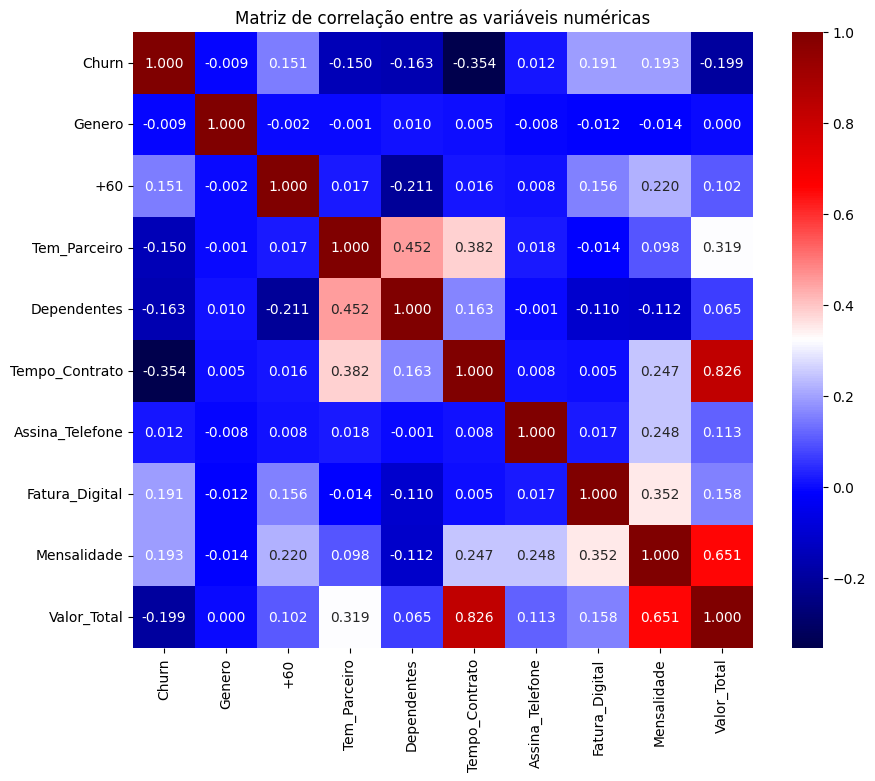

In [10]:
# Gera visualização da matriz de correlação:
plt.figure(figsize=(10,8))
sns.heatmap(Matriz_Correlacao, annot=True, cmap="seismic", fmt=".3f")
plt.title("Matriz de correlação entre as variáveis numéricas")
plt.show()


## 2. Infere sobre a correlação entre Evasão e as variáveis categóricas:

In [11]:
# Cria um novo DF só com variáveis categóricas
Colunas_Categ = DF.select_dtypes(include=["object"]).columns
DF_categ = DF[Colunas_Categ]
DF_categ.head(1)

,Mult_Linhas,Tipo_Net,Seg_Online,Backup_Online,Prot_Disp,Suporte_Tec,StreamTV,StreamFilmes,Tipo_Contrato,Met_Pag
0,No,DSL,No,Yes,No,Yes,Yes,No,One year,Mailed check


In [12]:
# Gera tabelas de porporção de Evasão para cada variável categórica presente na lista Colunas_Categ:
for coluna in Colunas_Categ:
    print(f"\n Coluna: {coluna}")
    # Tabela de porcentagem de EVASÃO para cada coluna categórica
    display(pd.crosstab(DF[coluna], DF["Churn"], normalize="index") * 100)


 Coluna: Mult_Linhas


Churn,0.0,1.0
Mult_Linhas,,
No,74.918759,25.081241
No phone service,75.000000,25.000000
Yes,71.351534,28.648466



 Coluna: Tipo_Net


Churn,0.0,1.0
Tipo_Net,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211



 Coluna: Seg_Online


...

Churn,0.0,1.0
StreamFilmes,,
No,66.271125,33.728875
No internet service,92.565789,7.434211
Yes,70.047602,29.952398



 Coluna: Tipo_Contrato


Churn,0.0,1.0
Tipo_Contrato,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665



 Coluna: Met_Pag


Churn,0.0,1.0
Met_Pag,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


Detectada pouca influência da variável categórica Multiplas Linhas sobre a variável alvo Evasão. Essa coluna possui pouca relevância e será eliminada.

#🔧 Transformação

## 1. Eliminando variáveis (colunas) com pouca correlação com a variável alvo (evasão):

In [13]:
# Eliminando Genero e Assina_Telefone, cuja correlação é em torno de 0,01
DF.drop(['Genero','Assina_Telefone'], axis=1, inplace=True)  # Variáveis numéricas irrelevantes
DF.drop(['Mult_Linhas'], axis=1, inplace=True)           # Variáveis categóricas irrelevantes

In [14]:
DF.head(1)

,Churn,+60,Tem_Parceiro,Dependentes,Tempo_Contrato,Tipo_Net,Seg_Online,Backup_Online,Prot_Disp,Suporte_Tec,StreamTV,StreamFilmes,Tipo_Contrato,Fatura_Digital,Met_Pag,Mensalidade,Valor_Total
0,0.0,0,1,1,9,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.3


## 🎯 Split

## 1. Separando variáveis explicativas da variável alvo (evasão):

In [15]:
# Separando o que é x e o que é y no DF:
X = DF.drop('Churn', axis = 1)
y = DF['Churn']

In [16]:
# Variáveis explicativas:
X.head(1)

,+60,Tem_Parceiro,Dependentes,Tempo_Contrato,Tipo_Net,Seg_Online,Backup_Online,Prot_Disp,Suporte_Tec,StreamTV,StreamFilmes,Tipo_Contrato,Fatura_Digital,Met_Pag,Mensalidade,Valor_Total
0,0,1,1,9,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.3


In [17]:
# Variável alvo:
y.head(1)

,Churn
0,0.0


In [18]:
X.columns

Index(['+60', 'Tem_Parceiro', 'Dependentes', 'Tempo_Contrato', 'Tipo_Net',
       'Seg_Online', 'Backup_Online', 'Prot_Disp', 'Suporte_Tec', 'StreamTV',
       'StreamFilmes', 'Tipo_Contrato', 'Fatura_Digital', 'Met_Pag',
       'Mensalidade', 'Valor_Total'],
      dtype='object')

## 2. Transformação das variáveis categóricas não boobleanas de x em variáveis boobleanas:

In [19]:
# Importando a biblioteca necessária:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [20]:
X.columns

Index(['+60', 'Tem_Parceiro', 'Dependentes', 'Tempo_Contrato', 'Tipo_Net',
       'Seg_Online', 'Backup_Online', 'Prot_Disp', 'Suporte_Tec', 'StreamTV',
       'StreamFilmes', 'Tipo_Contrato', 'Fatura_Digital', 'Met_Pag',
       'Mensalidade', 'Valor_Total'],
      dtype='object')

In [21]:
colunas = X.columns

In [22]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    [ 'Tipo_Net', 'Seg_Online', 'Backup_Online', 'Prot_Disp', 'Suporte_Tec', 'StreamTV', 'StreamFilmes', 'Tipo_Contrato', 'Met_Pag']
),    remainder = 'passthrough' ,  verbose_feature_names_out=False  ,  sparse_threshold=1)

In [23]:
x = one_hot.fit_transform(X)

In [24]:
x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 95186 stored elements and shape (7032, 35)>

In [25]:
x = x.toarray()

In [26]:
x

array([[1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        6.56000e+01, 5.93300e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        5.99000e+01, 5.42400e+02],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        7.39000e+01, 2.80850e+02],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        5.03000e+01, 9.27500e+01],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        6.78500e+01, 4.62765e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        5.90000e+01, 3.70760e+03]])

In [27]:
one_hot.get_feature_names_out(colunas)

array(['Tipo_Net_DSL', 'Tipo_Net_Fiber optic', 'Tipo_Net_No',
       'Seg_Online_No', 'Seg_Online_No internet service',
       'Seg_Online_Yes', 'Backup_Online_No',
       'Backup_Online_No internet service', 'Backup_Online_Yes',
       'Prot_Disp_No', 'Prot_Disp_No internet service', 'Prot_Disp_Yes',
       'Suporte_Tec_No', 'Suporte_Tec_No internet service',
       'Suporte_Tec_Yes', 'StreamTV_No', 'StreamTV_No internet service',
       'StreamTV_Yes', 'StreamFilmes_No',
       'StreamFilmes_No internet service', 'StreamFilmes_Yes',
       'Tipo_Contrato_Month-to-month', 'Tipo_Contrato_One year',
       'Tipo_Contrato_Two year', 'Met_Pag_Bank transfer (automatic)',
       'Met_Pag_Credit card (automatic)', 'Met_Pag_Electronic check',
       'Met_Pag_Mailed check', '+60', 'Tem_Parceiro', 'Dependentes',
       'Tempo_Contrato', 'Fatura_Digital', 'Mensalidade', 'Valor_Total'],
      dtype=object)

In [28]:
# Como ficaria x se fosse transformado em um DF:
pd.DataFrame(x, columns = one_hot.get_feature_names_out(colunas)).head(1)

,Tipo_Net_DSL,Tipo_Net_Fiber optic,Tipo_Net_No,Seg_Online_No,Seg_Online_No internet service,Seg_Online_Yes,Backup_Online_No,Backup_Online_No internet service,Backup_Online_Yes,Prot_Disp_No,...,Met_Pag_Credit card (automatic),Met_Pag_Electronic check,Met_Pag_Mailed check,+60,Tem_Parceiro,Dependentes,Tempo_Contrato,Fatura_Digital,Mensalidade,Valor_Total
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,1.0,9.0,1.0,65.6,593.3


In [29]:
# Nomes das novas colunas (variáveis explicativas):
nome_colunas1 = pd.Series(one_hot.get_feature_names_out(colunas))  # Em forma de DF
nome_colunas2 = list(one_hot.get_feature_names_out(colunas))  # Em forma de lista

## 3. Normalização das variáveis explicativas numéricas (Tempo_Contrato, Mensalidade e Valor_Total):

In [30]:
from sklearn.preprocessing import MinMaxScaler

In [31]:
normalizacao = MinMaxScaler()
x_normalizado = normalizacao.fit_transform(x)

In [32]:
pd.DataFrame(x_normalizado, columns = one_hot.get_feature_names_out(colunas))

,Tipo_Net_DSL,Tipo_Net_Fiber optic,Tipo_Net_No,Seg_Online_No,Seg_Online_No internet service,Seg_Online_Yes,Backup_Online_No,Backup_Online_No internet service,Backup_Online_Yes,Prot_Disp_No,...,Met_Pag_Credit card (automatic),Met_Pag_Electronic check,Met_Pag_Mailed check,+60,Tem_Parceiro,Dependentes,Tempo_Contrato,Fatura_Digital,Mensalidade,Valor_Total
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.112676,1.0,0.471144,0.066294
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.112676,0.0,0.414428,0.060420
2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.042254,1.0,0.553731,0.030239
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.169014,1.0,0.793532,0.140670
4,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.028169,1.0,0.653234,0.028687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.169014,0.0,0.367164,0.083556
7028,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.295775,1.0,0.665174,0.214043
7029,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.014085,1.0,0.318905,0.008533
7030,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.929577,0.0,0.493532,0.531831


## 4. Separando os dados em 2 partes: 75% p/ treinamento e 25% p/ validação dos modelos.

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
# Separa os dados:
semente = 42
x_treino_norm, x_teste_norm, y_treino, y_teste = train_test_split(x_normalizado, y, stratify = y,  random_state = semente)

In [35]:
pd.DataFrame(x_treino_norm)

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.140845,1.0,0.009950,0.018636
1,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.140845,1.0,0.579602,0.094525
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.126761,0.0,0.612935,0.089828
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.000000,1.0,0.656219,0.688640
4,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.669652,0.007703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5269,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.098592,0.0,0.012438,0.016219
5270,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.915493,0.0,0.111443,0.226673
5271,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.957746,1.0,0.629353,0.638640
5272,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.309859,0.0,0.013930,0.048246


## 5. Treinamento e teste do modelo no. 1: Árvore de Decisão

In [36]:
from sklearn.metrics import classification_report

In [37]:
# Importando biblioteca de treinamento do modelo Árvore de Decisão:
from sklearn.tree import DecisionTreeClassifier

In [38]:
# Treina ou ajusta o modelo aos dados de treinamento:
Profundidade = 4
Modelo_Arvore_Decisao = DecisionTreeClassifier(max_depth = Profundidade, random_state = semente)
Modelo_Arvore_Decisao.fit(x_treino_norm, y_treino)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [39]:
# Gera uma previsão a partir do subset de dados de teste:
Y = Modelo_Arvore_Decisao.predict(x_teste_norm)

In [40]:
# Previsão de taxa de evasão (%) dentro do subset de teste:
print("Previsão de evasão de {:.2f} %".format(100*(sum(Y==1)/len(Y))))

Previsão de evasão de 21.73 %


In [41]:
# Avalia acurácia do modelo treinado comparando a previsão Y com o valor esperado y_teste:
Modelo_Arvore_Decisao.score(x_teste_norm, y_teste)

0.7946530147895335

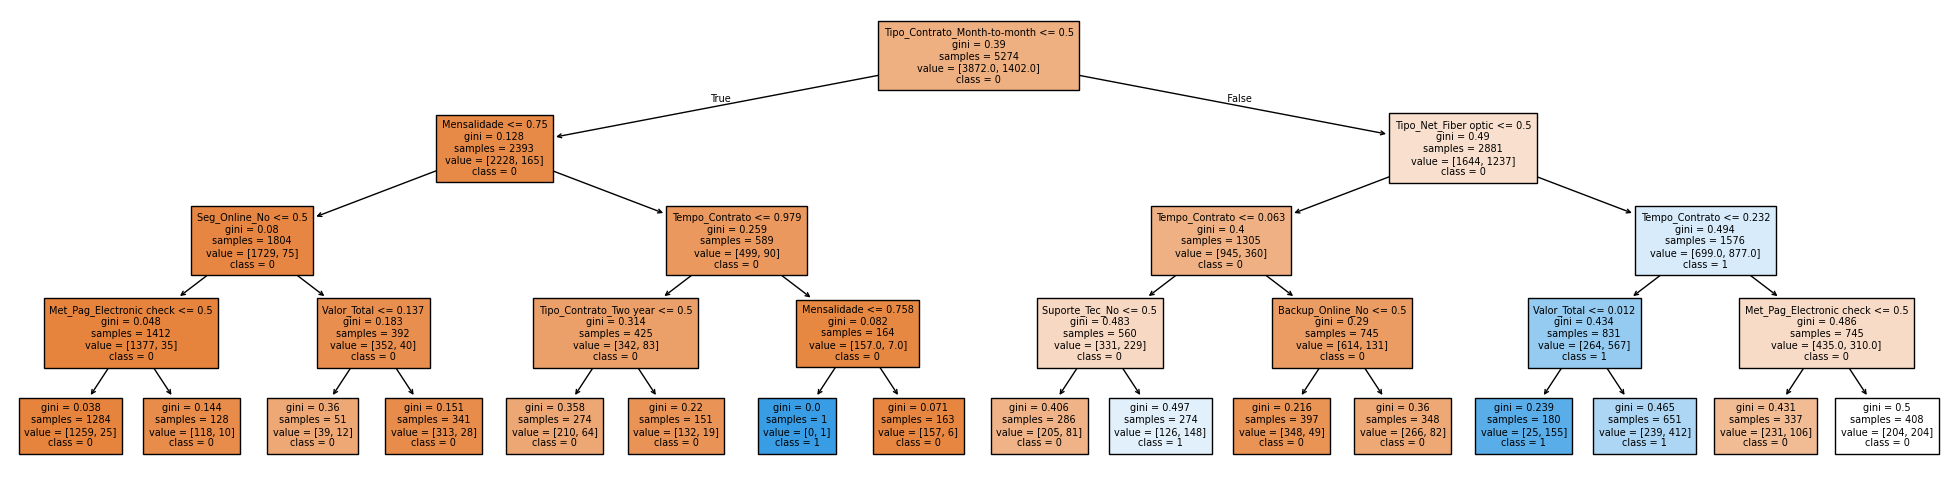

In [42]:
# Desenha a Árvore de Decisão gerada:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize = (25, 6))
plot_tree(Modelo_Arvore_Decisao, filled = True, class_names = ['0', '1'], fontsize = 7, feature_names = nome_colunas2);

## 6. Treinamento e teste do modelo no. 2:  KNN

**Observação:** os dados foram normalizados antes do treinamento do modelo Árvore de Decisão, não sendo necessária a sua normaliação agora.

In [43]:

from sklearn.neighbors import KNeighborsClassifier

In [44]:
# Treina ou ajusta o modelo aos dados de treinamento:
Modelo_KNN = KNeighborsClassifier()
Modelo_KNN.fit(x_treino_norm, y_treino)

KNeighborsClassifier()

In [45]:
# Gera uma previsão a partir do subset de dados de teste:
Y = Modelo_KNN.predict(x_teste_norm)

In [46]:
# Previsão de taxa de evasão (%) dentro do subset de teste:
print("Previsão de evasão de {:.2f} %".format(100*(sum(Y==1)/len(Y))))

Previsão de evasão de 23.72 %


In [47]:
# Avalia acurácia do modelo treinado comparando a previsão Y com o valor esperado y_teste:
Modelo_KNN.score(x_teste_norm, y_teste)

0.7679180887372014

## 7. Modelo Random Forest Classifier:

In [48]:
# Importando biblioteca de treinamento do modelo RFC:
from sklearn.ensemble import RandomForestClassifier

In [49]:
# Treina ou ajusta o modelo aos dados de treinamento:
Modelo_RFC = RandomForestClassifier(n_estimators=200, random_state=42)
Modelo_RFC.fit(x_treino_norm, y_treino)

RandomForestClassifier(n_estimators=200, random_state=42)

In [50]:
# Gera uma previsão a partir do subset de dados de teste:
Y = Modelo_RFC.predict(x_teste_norm)

In [51]:
# Avalia acurácia do modelo treinado comparando a previsão Y com o valor esperado y_teste:
classification_report(y_teste, Y)

'              precision    recall  f1-score   support\n\n         0.0       0.83      0.88      0.86      1291\n         1.0       0.61      0.49      0.54       467\n\n    accuracy                           0.78      1758\n   macro avg       0.72      0.69      0.70      1758\nweighted avg       0.77      0.78      0.77      1758\n'

## 8. Criação do modelo de comparação ou de base:

In [52]:
# Importando biblioteca de treinamento do modelo de base:
from sklearn.dummy import DummyClassifier

In [53]:
# Treina ou ajusta o modelo aos dados de treinamento:
dummy = DummyClassifier()
dummy.fit(x_treino_norm, y_treino)

DummyClassifier()

In [54]:
# Avalia acurácia do modelo de base:
dummy.score(x_teste_norm, y_teste)

0.7343572241183163

## 9. Comparação da acurácia dos modelos gerados:

In [55]:
print(f'A acurácia do modelo de base (Dummy) foi de: {dummy.score(x_teste_norm, y_teste)}')
print(f'A acurácia da Árvore de Decisão de {Profundidade} níveis foi de: {Modelo_Arvore_Decisao.score(x_teste_norm, y_teste)}')
print(f'A acurácia no modelo de vizinhança (KNN) foi de: {Modelo_KNN.score(x_teste_norm, y_teste)}')

A acurácia do modelo de base (Dummy) foi de: 0.7343572241183163
A acurácia da Árvore de Decisão de 4 níveis foi de: 0.7946530147895335
A acurácia no modelo de vizinhança (KNN) foi de: 0.7679180887372014


## 10. Salvando o melhor modelo em um arquivo serializado:

_______________________________________________________________________________
_______________________________________________________________________________
_______________________________________________________________________________
_______________________________________________________________________________

#📄Relatorio Final

# **Relatório Final**

**Assunto**: Elaboração de Modelo Machine Learning para previsão de evasão de clientes da empresa Telecom X

**Interessado / contratante da análise**:   TELECON X


## **1. Objetivos da análise**

O objetivo da presente análise é tratar e ajustar os dados da empresa Telecon X (registros de clientes) de forma a usá-lo para desenvolver modelos de Machine Learning capazes de prever a possibilidade de evasão de determinados clientes com base nas informações do mesmo (variáveis explicativas).

Foram usados, para esse fim, os dados já limpos e tratados produzidos na etapa anterior, ou seja, no desafio TELECON X PARTE 1.


## **2. Metodologia**

De forma a se tentar determinar uma causa para o percentual de evasão observado dentre os clientes da TELECOM X, utilizou-se um DataFrame contendo aproximadamente 7000 registros de clientes. Cada um destes resistros contem:

*   O cliente evadiu? Sim ou não;
*   Dados do cliente: genero, se é idoso,se tem parceiro, se tem dependentes;
*   Serviços contratados: telefone, internet, serviços de segurança, backup, etc;
*   Dados do contrato: tempo de permanencia, forma de pagamento, valores, boleto impresso ou digital.

A partir do volume de dados disponibilizados, buscou-se encontrar correlações entre a ocorrência ou não de evasão e as demais variáveis listadas acima. Para tal foram gerados gráficos diversos, como gráficos de barra, de linha, de distribuição e histogramas.


## **3. Resultados Encontrados**

A taxa de evasão encontrada nos registros disponibilizados é de 26,58%, com evasão de 1869 clientes de um universo de 7.032 registros. O gráfico abaixo apresenta uma visualização desta proporção.
